In [1]:
import forte2
import numpy as np
import matplotlib.pyplot as plt
import time

In [2]:
det = forte2.hilbert_space(5,2,2)
det[20].str(5)[2]

creop = forte2.SparseOperator()
creop.add('2a+1a-')

wfxn2 = forte2.SparseState()
wfxn2.add(det[30],1)

f1 = creop @ wfxn2
print(f1)

for i in range(0,len(det)):
    wfxn3 = forte2.SparseState()
    wfxn3.add(det[i],1)
    #print(f1.overlap(wfxn3))
    if f1.overlap(wfxn3) != 0:
        print("yay")


|00ab200000000000000000000000000000000000000000000000000000000000> * (1.00000000,0.00000000)

yay


In [3]:
det = forte2.hilbert_space(5,2,2)
det[20].str(5)[2]

'0'

In [4]:
def hubbard_hamiltonian(nsites,nalpha,nbeta,U,T):
    dets = forte2.hilbert_space(nsites,nalpha,nbeta)
    H = np.zeros((len(dets), len(dets)))
    #diagonal: if site is doubly occupied, H[m,m]=U
    for j in range(0,len(dets)):
        for i in range(0,nsites):
            var = str(dets[j].str(nsites)[i+1])
            if (str(var) == '2'):
                H[j,j] += U
            else:
                H[j,j] += 0
    #off:diagonal: if annop(site) and creop(site+1) both are allowed, H[mn] = t
        wfxn = forte2.SparseState()
        wfxn.add(dets[j],1)
        #site 1->2; alpha or beta
        for k in range(0,nsites-1):
            alpha = forte2.SparseOperator()
            alpha.add(f"[{k+1}a+{k}a-]",1.0)
            f1 = alpha @ wfxn
            if f1: 
                for m in range(0,len(dets)):
                    wfxn2 = forte2.SparseState()
                    wfxn2.add(dets[m],1)
                    if f1.overlap(wfxn2) != 0:
                        H[m,j] += -T
            beta = forte2.SparseOperator()
            beta.add(f"[{k+1}b+{k}b-]",1.0)
            f2 = beta @ wfxn
            if f2: 
                for n in range(0,len(dets)):
                    wfxn2 = forte2.SparseState()
                    wfxn2.add(dets[n],1)
                    if f2.overlap(wfxn2) != 0:
                        H[n,j] += -T
        #site 2->1; alpha or beta... Redundant?
        for l in range(0,nsites-1):
            alpha = forte2.SparseOperator()
            alpha.add(f"[{l}a+{l+1}a-]",1.0)
            f1 = alpha @ wfxn
            if f1: 
                for m in range(0,len(dets)):
                    wfxn2 = forte2.SparseState()
                    wfxn2.add(dets[m],1)
                    if f1.overlap(wfxn2) != 0:
                        H[m,j] += -T
            beta = forte2.SparseOperator()
            beta.add(f"[{l}b+{l+1}b-]",1.0)
            f2 = beta @ wfxn
            if f2: 
                for n in range(0,len(dets)):
                    wfxn2 = forte2.SparseState()
                    wfxn2.add(dets[n],1)
                    if f2.overlap(wfxn2) != 0:
                        H[n,j] += -T
            
    return H, dets
    
H = hubbard_hamiltonian(2,1,1,4,1)[0]
print(H)
evals, evecs = np.linalg.eigh(H)
print(evals)


[[ 4. -1. -1.  0.]
 [-1.  0.  0. -1.]
 [-1.  0.  0. -1.]
 [ 0. -1. -1.  4.]]
[-0.82842712  0.          4.          4.82842712]


[|00a0000000000000000000000000000000000000000000000000000000000000>, |0a00000000000000000000000000000000000000000000000000000000000000>, |a000000000000000000000000000000000000000000000000000000000000000>]


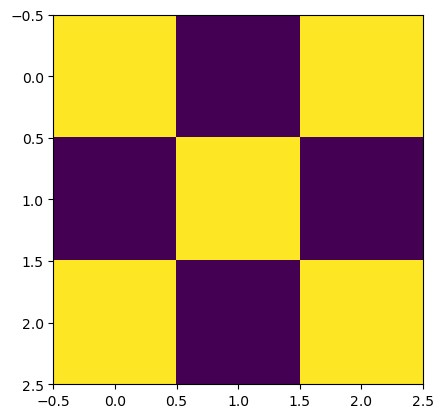

In [5]:
plt.imshow(hubbard_hamiltonian(3,1,0,1,3)[0])
print(hubbard_hamiltonian(3,1,0,1,3)[1])

In [6]:
#import time

#start = time.monotonic()

#H = hubbard_hamiltonian(8,4,4,4,1)[0]

#end = time.monotonic()

#print(end-start)
#print(H)

In [7]:
def hubbard_hamiltonian_v2(nsites,nalpha,nbeta,U,T):
    dets = forte2.hilbert_space(nsites,nalpha,nbeta)
    ndets = len(dets)
    H = np.zeros((ndets,ndets))

    #instead of building sparse state inside every loop, define a determinant index map
    dets_i = {dets[i]: i for i in range(ndets)}

    #diagonal: if site is doubly occupied, H[m,m]=U
    for j in range(0,len(dets)):
        for i in range(0,nsites):
            var = str(dets[j].str(nsites)[i+1])
            if (str(var) == '2'):
                H[j,j] += U
    
    #off:diagonal: if annop(site) and creop(site+1) both are allowed, H[mn] = t
    #replace each individual loop with pre-built operators and states
    #also don't need to do k+1,k and k,k+1 --> use symmetry instead
    alpha_ops = []
    beta_ops = []
    for k in range(nsites-1):
        alpha = forte2.SparseOperator()
        alpha.add(f"[{k+1}a+{k}a-]")
        alpha_ops.append(alpha)
        beta = forte2.SparseOperator()
        beta.add(f"[{k+1}b+{k}b-]")
        beta_ops.append(beta)
    for j, det in enumerate(dets): #loops through both j and dets[j]
        wfxn = forte2.SparseState()
        wfxn.add(det,1.0)
        for op in (alpha_ops + beta_ops):
            f = op @ wfxn
            if f:
                for new_det, coeff in f.items():
                    i = dets_i[new_det]
                    H[i,j] += -T 
    H = H + H.T - np.diag(np.diag(H)) #copies symmetry into lower triangular without re-looping
    return H, dets

In [8]:
H = hubbard_hamiltonian_v2(2,1,1,4,1)[0]
print(H)
evals, evecs = np.linalg.eigh(H)
print(evals)

[[ 4. -1. -1.  0.]
 [-1.  0.  0. -1.]
 [-1.  0.  0. -1.]
 [ 0. -1. -1.  4.]]
[-0.82842712  0.          4.          4.82842712]


In [9]:
import time

start = time.monotonic()

H = hubbard_hamiltonian_v2(10,3,3,4,1)[0]

end = time.monotonic()

print(end-start)
print(H)

9.261837981001008
[[12. -1.  0. ...  0.  0.  0.]
 [-1.  8. -1. ...  0.  0.  0.]
 [ 0. -1.  8. ...  0.  0.  0.]
 ...
 [ 0.  0.  0. ...  8. -1.  0.]
 [ 0.  0.  0. ... -1.  8. -1.]
 [ 0.  0.  0. ...  0. -1. 12.]]


In [10]:
start = time.monotonic()

#H = hubbard_hamiltonian(10,3,3,4,1)[0]

end = time.monotonic()

print(end-start)
#print(H)

2.1907999325776473e-05
